In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")   
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

Shape: (200, 13)

Columns: Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')

Missing Values:
 Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)       

In [5]:
print(df.columns)

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')


In [8]:
# Convert population to actual number
df["Population_Total"] = df["Population (in millions)"] * 1_000_000

# Total Energy Consumption (in MWh)
df["Total_Energy_Consumption_MWh"] = (
    df["Energy_Consumption_Per_Capita (in MWh)"] * df["Population_Total"]
)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Population_Total,Total_Energy_Consumption_MWh,Energy_Recovered_MWh
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,42220000.0,5.302832e+08,158140.0
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,137250000.0,7.178175e+08,498040.0
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,124470000.0,1.636780e+09,489510.0
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,67800000.0,5.288400e+07,145180.0
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,186520000.0,2.394917e+09,40380.0


In [9]:
# Convert GWh to MWh
df["Energy_Recovered_MWh"] = df["Energy_Recovered (in GWh)"] * 1000

In [10]:
df["Energy_Recovery_Rate"] = (
    df["Energy_Recovered_MWh"] / df["Total_Energy_Consumption_MWh"]
)

df[["Country", "Energy_Recovery_Rate"]].head()

,Country,Energy_Recovery_Rate
0,Hungary,0.000298
1,Singapore,0.000694
2,Romania,0.000299
3,Cook Islands,0.002745
4,Djibouti,0.000017


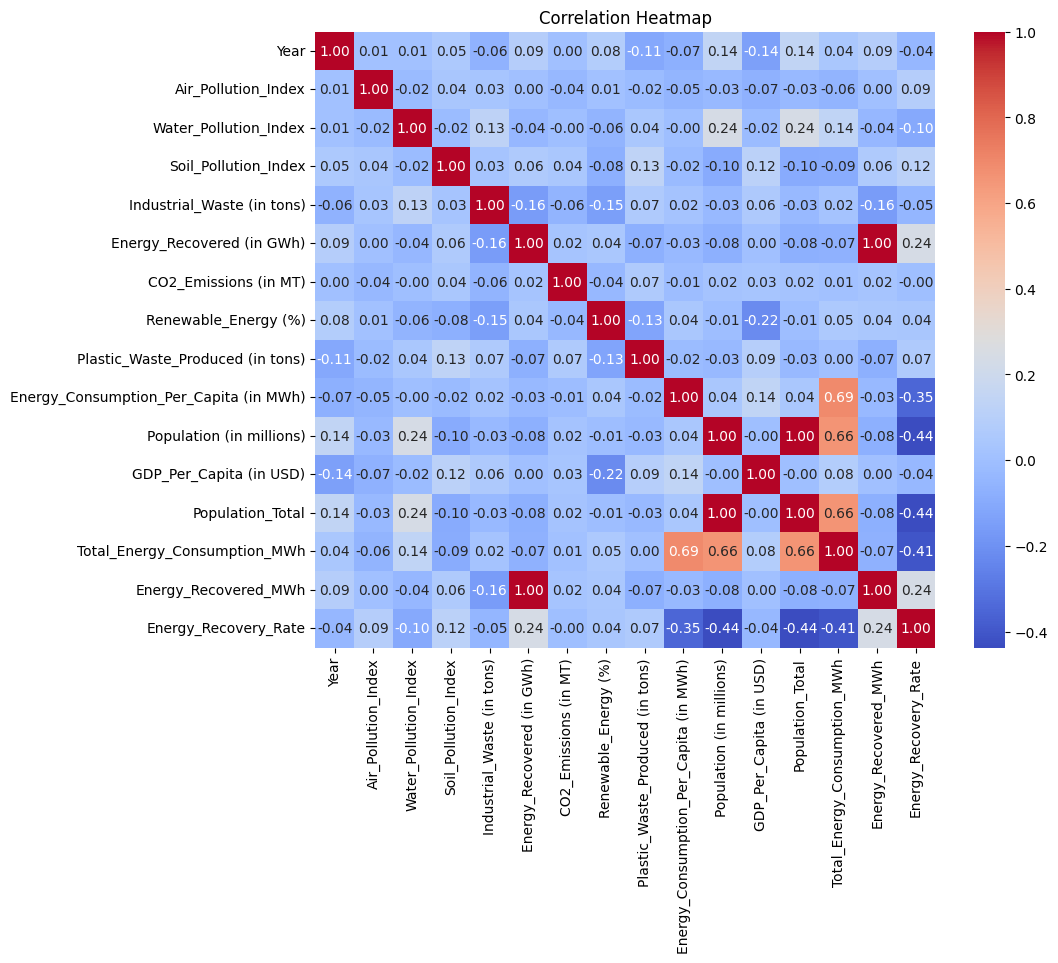

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

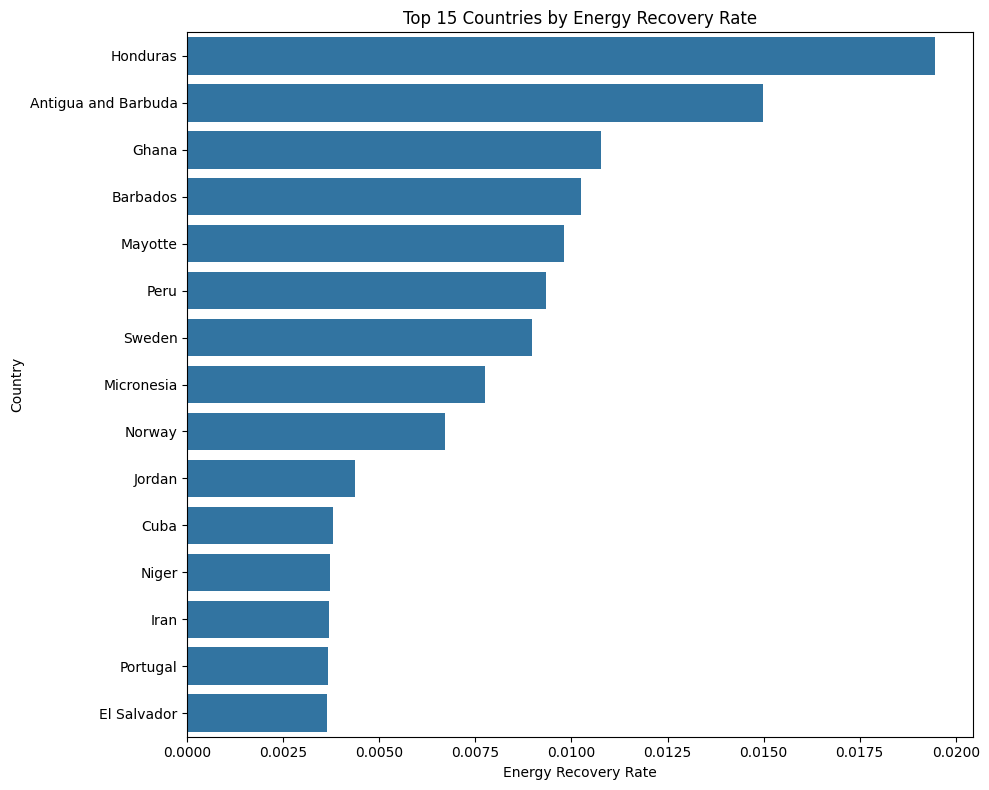

In [14]:
# Sort countries by Energy Recovery Rate
top_countries = df.sort_values(
    by="Energy_Recovery_Rate", 
    ascending=False
).head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_countries,
    y="Country",
    x="Energy_Recovery_Rate"
)

plt.title("Top 15 Countries by Energy Recovery Rate")
plt.xlabel("Energy Recovery Rate")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [15]:
y = df["Energy_Recovery_Rate"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (160, 10)
Testing shape: (40, 10)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_lin))
print("MAE:", mean_absolute_error(y_test, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))

Linear Regression Results
R2 Score: 0.11806079775166722
MAE: 0.0012681165454332126
RMSE: 0.0017284508564062776


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


Random Forest Results
R2 Score: 0.4021261998915726
MAE: 0.0007559431765805365
RMSE: 0.0014231231177082035


In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
8,Population (in millions),0.456177
7,Energy_Consumption_Per_Capita (in MWh),0.336164
2,Soil_Pollution_Index,0.046548
6,Plastic_Waste_Produced (in tons),0.034259
4,CO2_Emissions (in MT),0.030441
1,Water_Pollution_Index,0.025353
9,GDP_Per_Capita (in USD),0.023610
5,Renewable_Energy (%),0.019275
3,Industrial_Waste (in tons),0.018012
0,Air_Pollution_Index,0.010160


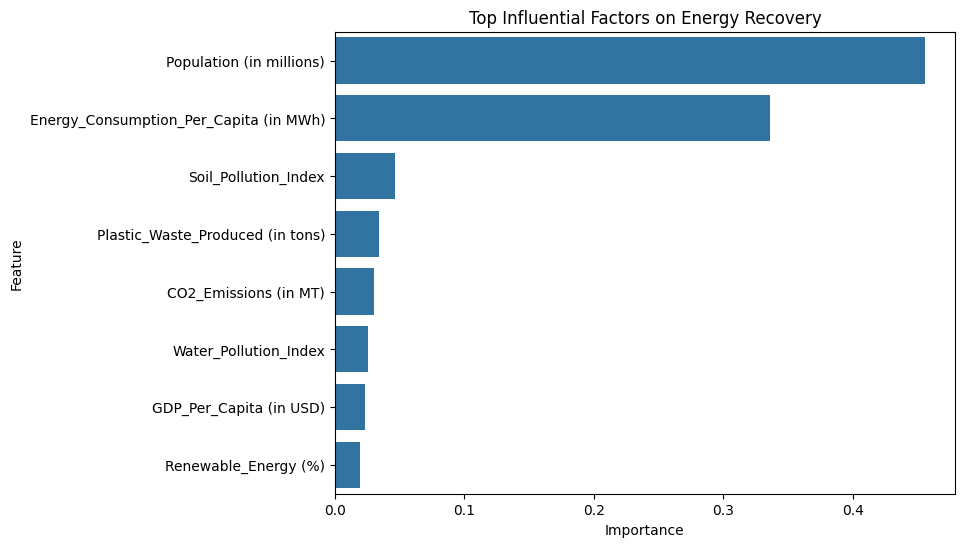

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(8),
    x="Importance",
    y="Feature"
)

plt.title("Top Influential Factors on Energy Recovery")
plt.show()

# Interpretation of Feature Importance

The Random Forest model identifies the most influential predictors of energy recovery efficiency.

GDP_Per_Capita (in USD) plays a significant role, indicating that economically advanced countries tend to have better energy infrastructure and technological efficiency.

Energy_Consumption_Per_Capita (in MWh) strongly impacts recovery rates, suggesting that energy intensity influences system performance.

Renewable_Energy (%) positively contributes to recovery efficiency, highlighting the role of clean energy integration.

CO2_Emissions (in MT) may reflect inefficiencies in fossil-fuel-based systems.

These results demonstrate that energy recovery efficiency is not solely dependent on total consumption but is strongly influenced by economic development and renewable integration.

# Model Comparison

The performance comparison between Linear Regression and Random Forest shows:

Linear Regression captures linear relationships but struggles with complex interactions.

Random Forest performs better due to its ability to model nonlinear relationships between GDP, energy consumption, emissions, and renewable share.

This suggests that energy recovery dynamics are nonlinear and influenced by multiple interacting factors.

# Policy Recommendations

Promote renewable energy integration to enhance recovery efficiency.

Improve grid modernization and industrial waste-to-energy systems.

Encourage energy-efficient production technologies in high GDP countries.

Reduce fossil fuel dependency to lower emissions and improve recovery performance.

# Final Conclusion

This study demonstrates that energy recovery efficiency is structurally linked to economic development, energy consumption intensity, and renewable energy integration. Countries with higher GDP per capita and greater renewable adoption exhibit better recovery performance.

The findings suggest that sustainable economic growth requires decoupling high energy consumption from inefficiency through technological innovation and clean energy policies.